<a href="https://colab.research.google.com/github/chaithanyakamath/dlTask2/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

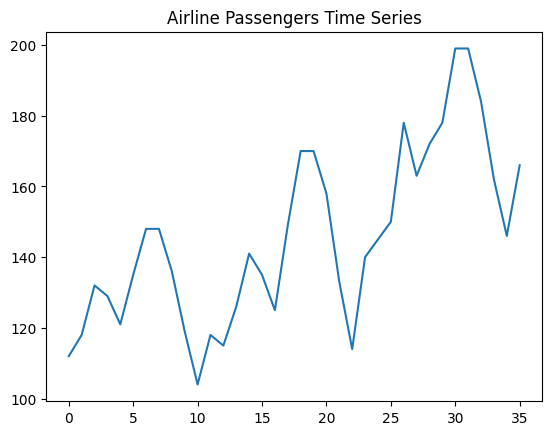

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset (monthly airline passengers)
data = [112,118,132,129,121,135,148,148,136,119,104,118,
        115,126,141,135,125,149,170,170,158,133,114,140,
        145,150,178,163,172,178,199,199,184,162,146,166]

data = np.array(data, dtype=float)

plt.plot(data)
plt.title("Airline Passengers Time Series")
plt.show()

In [2]:
def create_dataset(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 5
X, y = create_dataset(data, seq_length)

# reshape for RNN: (samples, time_steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape, y.shape)

(31, 5, 1) (31,)


In [3]:
def create_dataset(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 5
X, y = create_dataset(data, seq_length)

# reshape for RNN: (samples, time_steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape, y.shape)

(31, 5, 1) (31,)


In [4]:
import torch
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [5]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [6]:
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [7]:
def train_model(model, X, y, epochs=50):
    device = torch.device("cpu")
    model.to(device)

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).view(-1,1)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        output = model(X_t)
        loss = criterion(output, y_t)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses, model

In [8]:
rnn_losses, rnn_model = train_model(RNNModel(), X, y)
lstm_losses, lstm_model = train_model(LSTMModel(), X, y)
gru_losses, gru_model = train_model(GRUModel(), X, y)

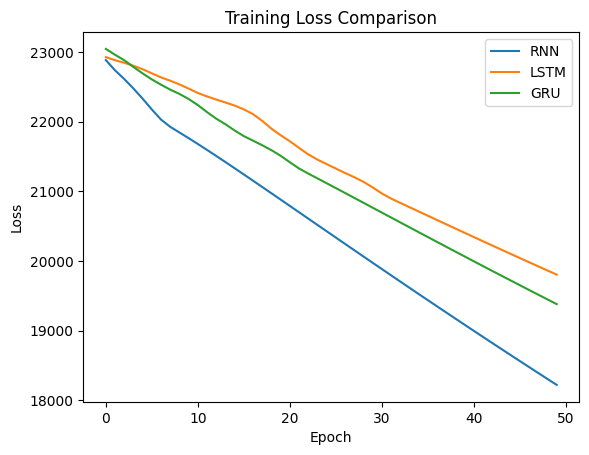

In [9]:
plt.plot(rnn_losses, label="RNN")
plt.plot(lstm_losses, label="LSTM")
plt.plot(gru_losses, label="GRU")
plt.legend()
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error

def evaluate(model, X, y):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    preds = model(X_t).detach().numpy()
    return np.sqrt(mean_squared_error(y, preds))

print("RNN RMSE:", evaluate(rnn_model, X, y))
print("LSTM RMSE:", evaluate(lstm_model, X, y))
print("GRU RMSE:", evaluate(gru_model, X, y))

RNN RMSE: 134.6736081958547
LSTM RMSE: 140.51970579121934
GRU RMSE: 138.97562263704762
